In [1]:
import os
import torch
from olmo.model import OLMo
import yaml
import torch.nn as nn
from collections import defaultdict
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm
from olmo.data import build_train_dataloader
from olmo.config import TrainConfig
from tqdm import tqdm
torch.set_grad_enabled(False)

# base_path = '/n/netscratch/kempner_sham_lab/Everyone/ameterez/random_basis/'
# run_name = '44081494_3'
# step = 'step1300-unsharded'

base_path = '/n/netscratch/kempner_sham_lab/Lab/dmorwani/checkpoints/'
run_name = '44386656_3'
step = 'step3200-unsharded'

experiment_path = os.path.join(base_path, run_name, step)
config_path = os.path.join(experiment_path, 'config.yaml')
optim_path = os.path.join(experiment_path, 'optim.pt')
model_path = os.path.join(experiment_path, 'model.pt')

In [2]:
with open(config_path, 'r') as file:
    config_data = yaml.safe_load(file)
optimizer_name = config_data['optimizer']['name']
print(optimizer_name)
model = OLMo.from_checkpoint(checkpoint_dir=experiment_path, device='cuda').eval()
optim = torch.load(optim_path)

# def get_one_batch(config_path):
#     cfg = TrainConfig.load(config_path)
#     cfg.data.num_workers = 1
#     cfg.global_train_batch_size = 128
#     train_loader = build_train_dataloader(cfg)
#     iterator = iter(train_loader)
#     batch = next(iterator)
#     input_ids = batch['input_ids'].to('cuda:0')

#     return input_ids
# batch = get_one_batch(config_path)
batch = torch.load("batch.pt")[:16, :]

adamw


In [3]:
@torch.no_grad()
def _rot2d(W, QL, QR, rot_type=1):
    if rot_type == 1:
        return QL.t() @ W @ QR
    if rot_type == 2:
        return QL.t() @ W
    if rot_type == 3:
        return W

@torch.no_grad()
def apply_rotation(model, optim, rot_type):
    name_to_param = dict(model.named_parameters())
    optim_keys = optim['state'].keys()
    with torch.no_grad():
        for name, tensor in model.state_dict().items():
            QL_cond = 'QL' in optim['state'][name] and optim['state'][name]['QL'] is not None
            QR_cond = 'QR' in optim['state'][name] and optim['state'][name]['QR'] is not None
            if not (QL_cond and QR_cond):
                continue
    
            QL, QR = optim['state'][name]['QL'], optim['state'][name]['QR']
            p = name_to_param[name]
            W = p.data
            QL = QL.to(W.device, W.dtype)
            QR = QR.to(W.device, W.dtype)
    
            W.copy_(_rot2d(W, QL, QR, rot_type))

@torch.no_grad()
def attach_linear_io_hooks(model: nn.Module):
    """
    Registers a forward hook on every nn.Linear.
    Captures (input, output) for each linear by its module name.
    Returns (handles, storage) so you can later remove hooks and plot.
    """
    storage: Dict[str, List[Tuple[torch.Tensor, torch.Tensor]]] = defaultdict(list)
    handles = []

    for name, mod in model.named_modules():
        if isinstance(mod, nn.Linear):
            def make_hook(mod_name):
                def hook(module, inputs, output):
                    x = inputs[0] if isinstance(inputs, (tuple, list)) else inputs
                    y = output if not isinstance(output, (tuple, list)) else output[0]
                    # move tiny snapshot to CPU for plotting
                    storage[mod_name].append((
                        x.detach().to("cpu").flatten().numpy(),
                        y.detach().to("cpu").flatten().numpy(),
                    ))
                return hook
            h = mod.register_forward_hook(make_hook(name))
            handles.append(h)

    return handles, storage
@torch.no_grad()
def remove_hooks(handles):
    for h in handles:
        try:
            h.remove()
        except:
            pass

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:41<00:00,  1.17it/s]


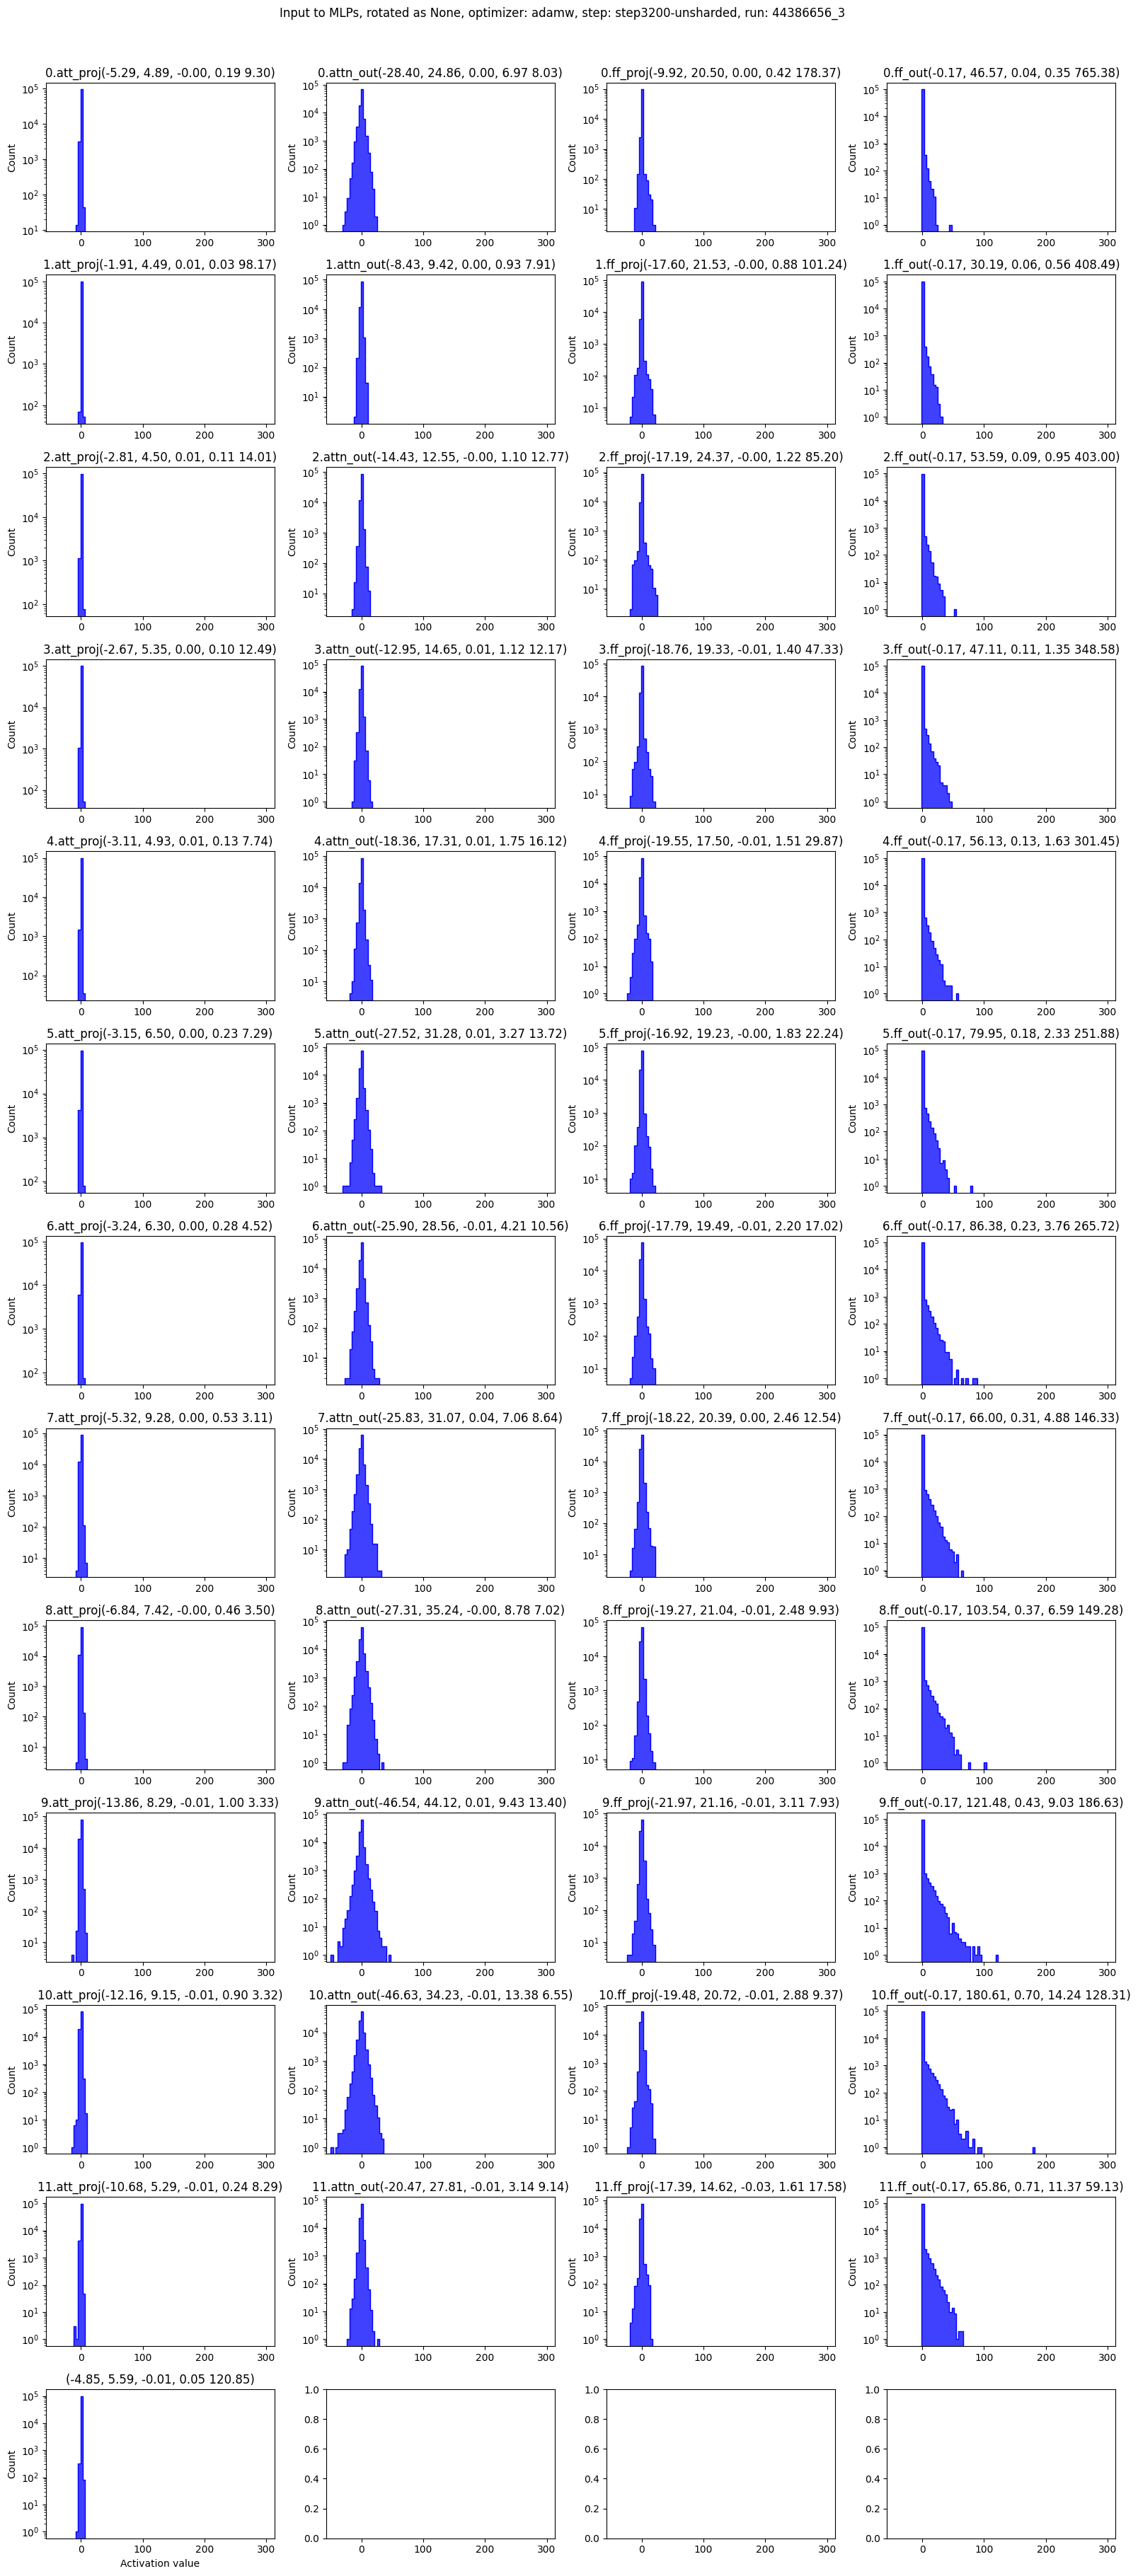

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [01:10<00:00,  1.43s/it]


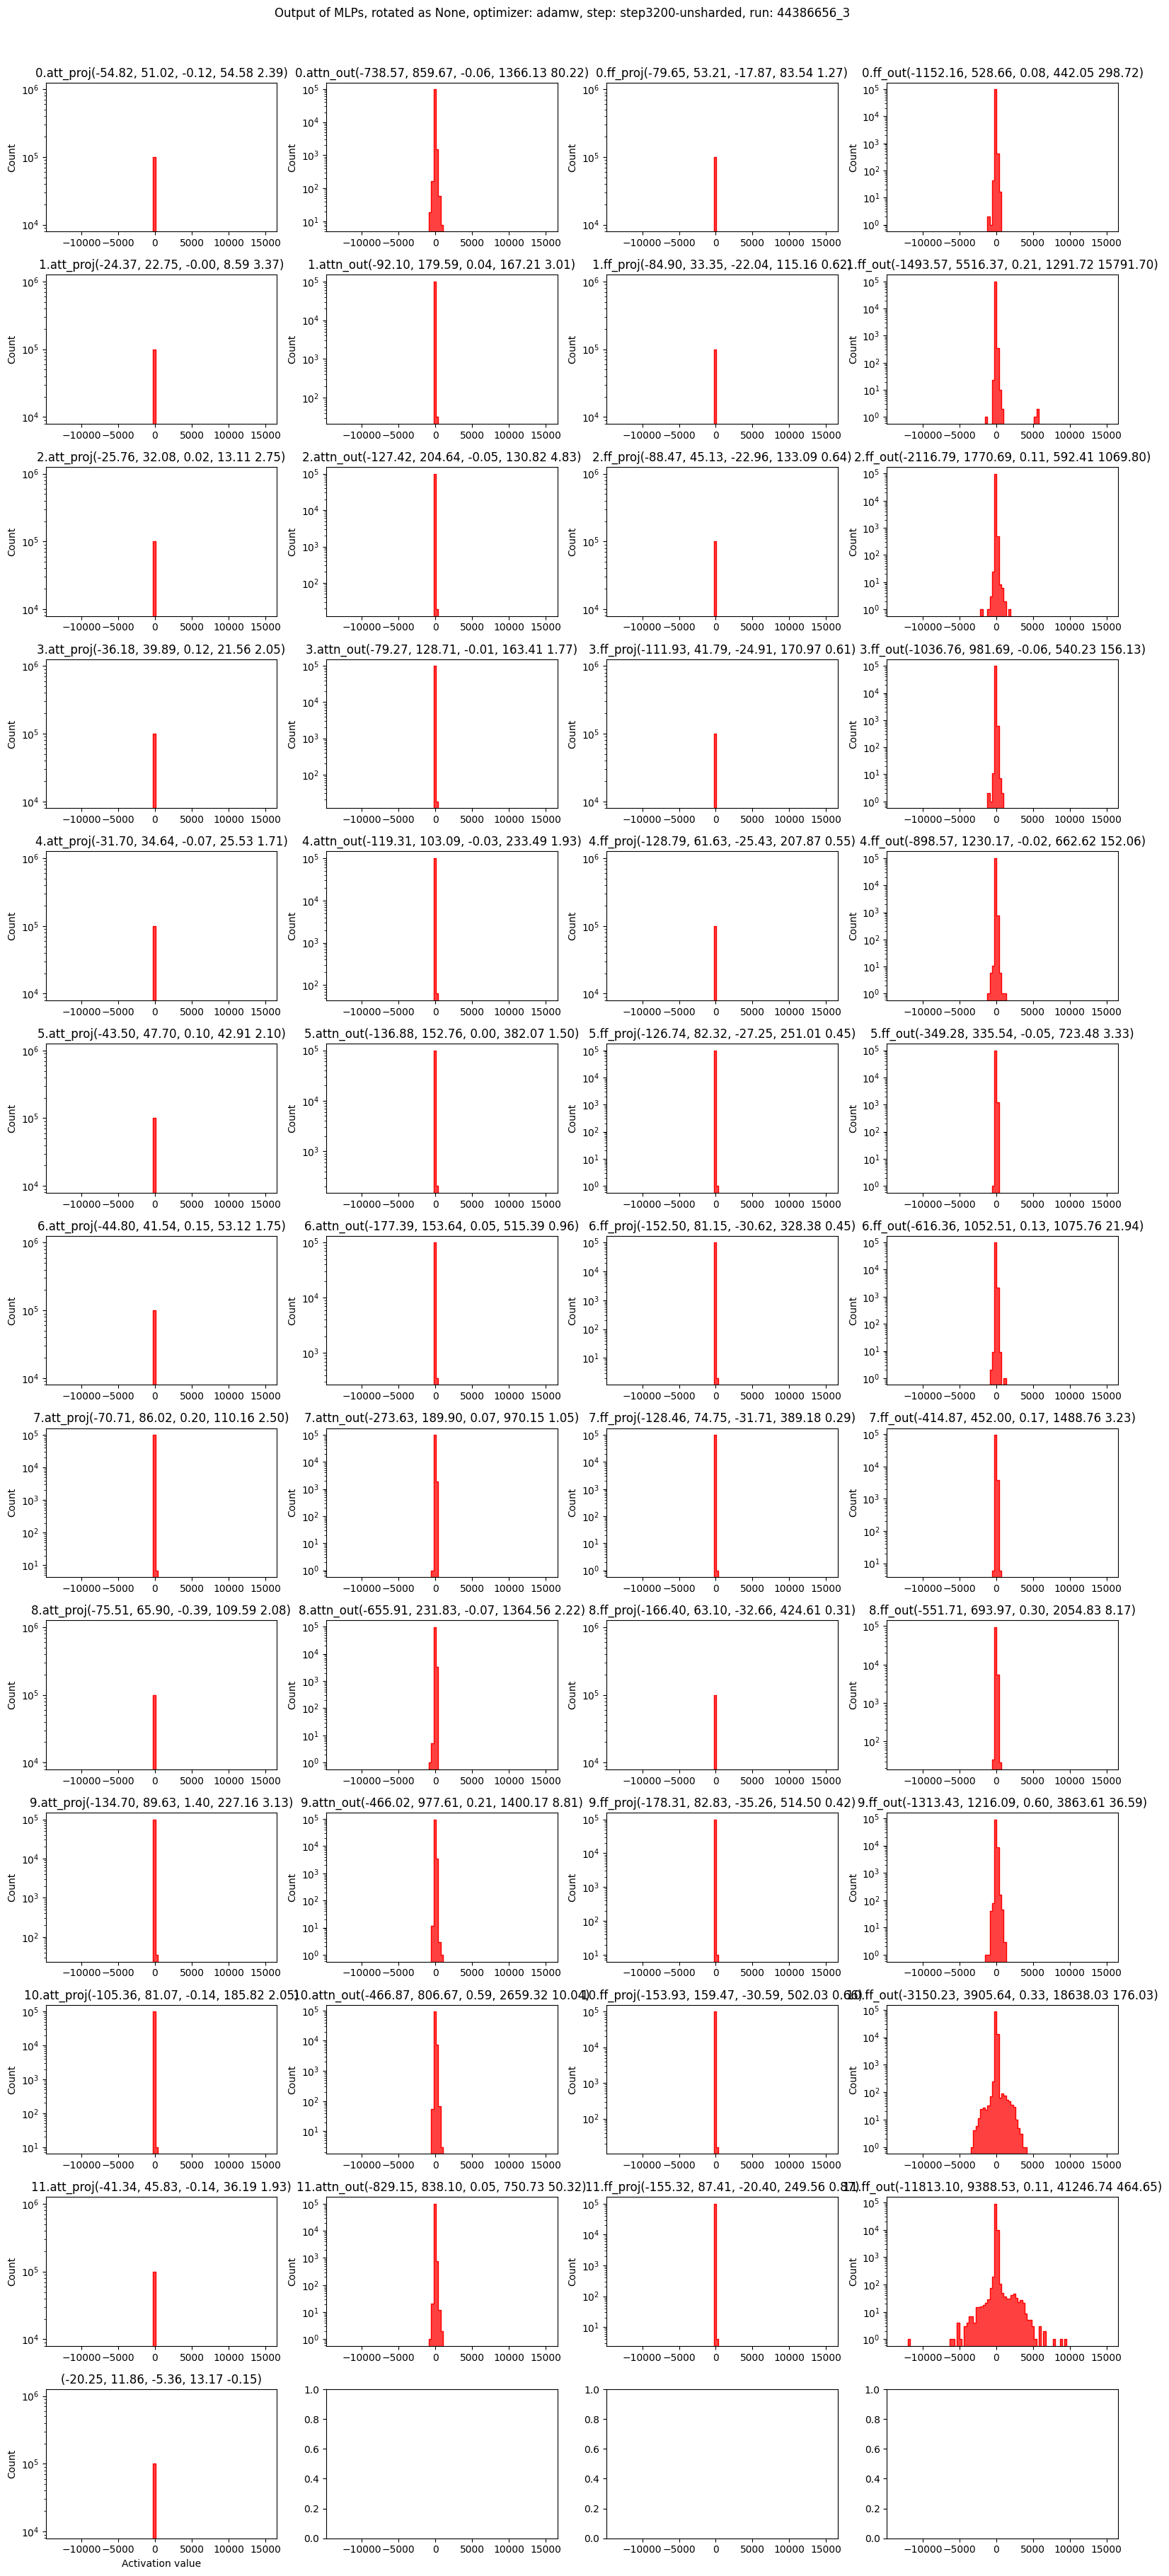

In [4]:
def get_statistics(arr):
    x = np.asarray(arr, dtype=float).ravel()
    mn = x.min()
    mx = x.max()
    mu = x.mean()
    v = ((x - mu) ** 2).mean()

    m4 = ((x - mu) ** 4).mean()
    ek = m4 / (v * v) - 3.0  # excess kurtosis (Fisher)
    return mn, mx, mu, v, ek


rot_type = 0
apply_rotation(model, optim, rot_type)

handles, storage = attach_linear_io_hooks(model)
with torch.no_grad():
    batch = batch.cuda()
    _ = model(batch)
rotated_as = 'None'
if rot_type == 1:
    rotated_as = 'QL^T W QR'
elif rot_type == 2:
    rotated_as = 'QL^T W'




# 1) Share x across all subplots
fig, ax = plt.subplots(figsize=(16, 36), ncols=4, nrows=13, sharex=True)
ax = ax.ravel()

# 2) (Recommended) Compute global x-range + common bin edges for fair comparison
import numpy as np
x_min, x_max = +np.inf, -np.inf
for k in storage:
    x = storage[k][0][0]
    x_min = min(x_min, np.nanmin(x))
    x_max = max(x_max, np.nanmax(x))

bins = np.linspace(x_min, x_max, 100)  # 200 bins => 201 edges
subsample = 100000
for i, k in enumerate(tqdm(storage.keys())):
    inputs = storage[k][0][0]
    inputs = np.random.choice(inputs, subsample, replace=False)

    # get statisitcs
    mn, mx, mu, v, ek = get_statistics(inputs)
    
    
    sns.histplot(inputs, bins=bins, stat="count", kde=False, element="step", ax=ax[i], color='blue')
    title = '.'.join(k.split('.')[2:])
    title += f'({mn:.2f}, {mx:.2f}, {mu:.2f}, {v:.2f} {ek:.2f})'
    ax[i].set_title(title)
    ax[i].set_xlabel("Activation value")
    ax[i].set_ylabel("Count")
    ax[i].set_yscale('log')
    ax[i].tick_params(axis='x', which='both', labelbottom=True) 
# 3) Enforce the same x-limits for all (sharex does this; setting once is enough)
ax[0].set_xlim(x_min, x_max)

fig.suptitle(f'Input to MLPs, rotated as {rotated_as}, optimizer: {optimizer_name}, step: {step}, run: {run_name}', y=1.01)
fig.tight_layout()
plt.show()
plt.close('all')



# 1) Share x across all subplots
fig, ax = plt.subplots(figsize=(16, 36), ncols=4, nrows=13, sharex=True)
ax = ax.ravel()

# 2) (Recommended) Compute global x-range + common bin edges for fair comparison
import numpy as np
x_min, x_max = +np.inf, -np.inf
for k in storage:
    x = storage[k][0][1]
    x_min = min(x_min, np.nanmin(x))
    x_max = max(x_max, np.nanmax(x))

bins = np.linspace(x_min, x_max, 100)  # 200 bins => 201 edges

for i, k in enumerate(tqdm(storage.keys())):
    outputs = storage[k][0][1]
    outputs = np.random.choice(outputs, subsample, replace=False)
    
    sns.histplot(outputs, bins=bins, stat="count", kde=False, element="step", ax=ax[i], color='red')
    title = '.'.join(k.split('.')[2:])
    mn, mx, mu, v, ek = get_statistics(outputs)
    title += f'({mn:.2f}, {mx:.2f}, {mu:.2f}, {v:.2f} {ek:.2f})'
    ax[i].set_title(title)
    ax[i].set_xlabel("Activation value")
    ax[i].set_ylabel("Count")
    ax[i].set_yscale('log')
    ax[i].tick_params(axis='x', which='both', labelbottom=True) 
# 3) Enforce the same x-limits for all (sharex does this; setting once is enough)
ax[0].set_xlim(x_min, x_max)
fig.suptitle(f'Output of MLPs, rotated as {rotated_as}, optimizer: {optimizer_name}, step: {step}, run: {run_name}', y=1.01)
fig.tight_layout()
plt.show()
plt.close('all')